# Final network-influence recovery analysis

This notebook is a **strict final-only companion** to
`analyze_final_paper_all_results_STRICT_FINAL_ONLY_FIXED.ipynb`.

It analyzes only the finalized September 17 experiments:

- single-shot: `broad_all_dynamics_multitopology_multiseed_unbounded_lambda1`
- abundant: `abundant_all_dynamics_multitopology_multiseed_unbounded_lambda1`

The goal here is to treat recovery of the weighted influence matrix \(A\) as a
first-class result, alongside prediction and control.

## Why a replay step is needed for single-shot

The abundant experiment saved the final \(\hat A\) directly. The single-shot
experiment saved the complete observed intermediate trajectories, training
seeds, final fit diagnostics, and control rollout, but **did not save**
the successive \(\hat A\) matrices.

Therefore this notebook reconstructs the single-shot final \(\hat A\) by
**deterministically replaying only the identifier optimization on the cached
observations**. It does not rerun the opinion-dynamics environment and does not
regenerate the controller trajectory.

Each reconstructed run is accepted only if:

1. the final replayed training MAE matches the cached final fit MAE;
2. the replayed model reproduces the cached next-campaign control actions;
3. all source/config/implementation provenance checks match the frozen final run.

The replayed matrices are stored in a separate derived-analysis cache so the
reconstruction only has to be performed once. **The notebook is directly
runnable with Run All; no launcher script is required.**

## Recovery metrics

For true weighted influence matrix \(A\) and estimate \(\hat A\):

\[
\mathrm{MAE}_A = \frac{1}{N^2}\sum_{ij} |\hat A_{ij}-A_{ij}|,
\]

\[
\overline{\mathrm{TV}}
= \frac{1}{N}\sum_i \frac12\sum_j |\hat A_{ij}-A_{ij}|.
\]

Because \(\hat A\) is dense while the true graph is sparse, we also report:

- **true-edge mass**: learned row probability mass placed on true edges;
- **top-degree support recall**: for each row, whether its top \(d_i\) learned
  neighbors recover the \(d_i\) true neighbors;
- **edge AP**: average precision when true nonzero entries are treated as edges
  and \(\hat A_{ij}\) is the ranking score;
- **centrality \(L_1\)**: error in the static graph-derived centrality vector.

For MAE, TV, Frobenius and centrality error, **lower is better**. For true-edge
mass, support recall and AP, **higher is better**.


In [1]:
from __future__ import annotations

import contextlib
import hashlib
import importlib
import io
import json
import math
import os
import random
import sys
from pathlib import Path
from typing import Any

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from scipy.stats import spearmanr, t as student_t

pd.set_option("display.max_columns", 240)
pd.set_option("display.width", 300)
pd.set_option("display.max_rows", 240)


def find_repo_root(start: Path | None = None) -> Path:
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "opinion_dynamics").exists():
            return candidate
    raise RuntimeError("Could not find repository root containing opinion_dynamics/.")


def read_json(path: Path) -> Any:
    return json.loads(path.read_text(encoding="utf-8"))


def sha256_file(path: Path) -> str:
    return hashlib.sha256(path.read_bytes()).hexdigest()


REPO_ROOT = find_repo_root()
RESULTS_ROOT = REPO_ROOT / "opinion_dynamics" / "experiments" / "results"

# Exact frozen final studies.
SS_STUDY = "broad_all_dynamics_multitopology_multiseed_unbounded_lambda1"
SS_PIPELINE = "2026-09-17-unbounded-lambda1-v1"
SS_CONFIG_HASH = "8521f6ff6ad1c49c2b9cdf0ff6cb143b751dc282bf65f7be6e62336b41643afa"
SS_RESULTS_DIR = RESULTS_ROOT / "experiment_2026_09_17_broad_all_dynamics_multitopology_multiseed_unbounded_lambda1"
SS_MANIFEST_PATH = SS_RESULTS_DIR / "RUN_MANIFEST.json"
SS_COMPLETION_PATH = SS_RESULTS_DIR / "COMPUTATION_COMPLETE.json"

AB_STUDY = "abundant_all_dynamics_multitopology_multiseed_unbounded_lambda1"
AB_PIPELINE = "2026-09-17-unbounded-lambda1-v1"
AB_CONFIG_HASH = "2dfd8a85437a16ee"
AB_RESULTS_DIR = RESULTS_ROOT / "experiment_2026_09_17_abundant_all_dynamics_multitopology_multiseed_unbounded_lambda1"
AB_COMPLETION_PATH = AB_RESULTS_DIR / "COMPUTATION_COMPLETE.json"

FINAL_IDENTIFIER = REPO_ROOT / "opinion_dynamics" / "identify_nonlinear_unbounded.py"
FINAL_HELPER = REPO_ROOT / "opinion_dynamics" / "experiments" / "online_single_shot_unbounded.py"
FINAL_ABUNDANT_NOTEBOOK = (
    REPO_ROOT / "opinion_dynamics" / "experiments"
    / "experiment_2026_09_17_abundant_all_dynamics_multitopology_multiseed_unbounded_lambda1.ipynb"
)

A_RECOVERY_DIR = RESULTS_ROOT / "final_A_recovery_analysis_2026_09_19"
DERIVED_SS_CACHE = A_RECOVERY_DIR / "derived_single_shot_A_cache"
TABLE_DIR = A_RECOVERY_DIR / "paper_tables"
PLOT_DIR = A_RECOVERY_DIR / "plots_paper_bw"
for d in [A_RECOVERY_DIR, DERIVED_SS_CACHE, TABLE_DIR, PLOT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Parallel reconstruction mode, matching the established experiment-launcher pattern.
NUM_SHARDS = 8
SHARD_ENV = "A_RECOVERY_SHARD_ID"
THREAD_ENV = "A_RECOVERY_TORCH_THREADS"
_shard_raw = os.environ.get(SHARD_ENV)
WORKER_MODE = _shard_raw is not None
SHARD_ID = int(_shard_raw) if WORKER_MODE else None
if WORKER_MODE and SHARD_ID not in range(NUM_SHARDS):
    raise ValueError(f"{SHARD_ENV} must be in 0..{NUM_SHARDS-1}; got {SHARD_ID}")

TORCH_THREADS = int(os.environ.get(THREAD_ENV, "2"))
torch.set_num_threads(max(1, TORCH_THREADS))
try:
    torch.set_num_interop_threads(1)
except RuntimeError:
    pass

print("Repository root:", REPO_ROOT)
print("Mode:", "A-recovery replay worker" if WORKER_MODE else "merge / analysis")
if WORKER_MODE:
    print("Shard:", f"{SHARD_ID+1}/{NUM_SHARDS}")
print("Torch threads:", torch.get_num_threads())
print("A-recovery output:", A_RECOVERY_DIR)


C:\Users\Chainsword\AppData\Local\Temp\ipykernel_54136\58207073.py:18: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


Repository root: d:\Work\repos\RL\unknown_graph_networks
Mode: merge / analysis
Torch threads: 2
A-recovery output: d:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\experiments\results\final_A_recovery_analysis_2026_09_19


## Strict provenance gate

No cache discovery or fallback is allowed here. The notebook refuses to analyze
anything other than the two frozen September final studies.


In [2]:
for path in [
    SS_MANIFEST_PATH,
    SS_COMPLETION_PATH,
    AB_COMPLETION_PATH,
    FINAL_IDENTIFIER,
    FINAL_HELPER,
    FINAL_ABUNDANT_NOTEBOOK,
]:
    if not path.exists():
        raise FileNotFoundError(path)

SS_MANIFEST = read_json(SS_MANIFEST_PATH)
SS_COMPLETION = read_json(SS_COMPLETION_PATH)
AB_COMPLETION = read_json(AB_COMPLETION_PATH)

# Single-shot exact provenance.
assert SS_MANIFEST["study_name"] == SS_STUDY
assert SS_MANIFEST["pipeline_version"] == SS_PIPELINE
assert SS_MANIFEST["config_hash"] == SS_CONFIG_HASH
assert float(SS_MANIFEST["scientific_config"]["lambda_mix"]) == 1.0
assert SS_MANIFEST["scientific_config"]["pipeline_version"] == SS_PIPELINE
assert int(SS_MANIFEST["n_environments"]) == 195
assert int(SS_MANIFEST["n_learned_runs_expected"]) == 585
assert list(SS_MANIFEST["learning_seeds"]) == [0, 1, 2]

SS_CACHE_ROOT = RESULTS_ROOT / "_trial_cache" / SS_STUDY
assert Path(SS_MANIFEST["cache_root"]).resolve() == SS_CACHE_ROOT.resolve()

assert SS_COMPLETION["status"] == "success"
assert SS_COMPLETION["study_name"] == SS_STUDY
assert SS_COMPLETION["config_hash"] == SS_CONFIG_HASH
assert SS_COMPLETION["implementation_hash"] == SS_MANIFEST["implementation_hash"]
assert int(SS_COMPLETION["n_environments"]) == 195
assert int(SS_COMPLETION["n_learned_runs"]) == 585

assert SS_MANIFEST["source_hashes"]["online_single_shot"] == sha256_file(FINAL_HELPER)

# Abundant exact provenance.
assert AB_COMPLETION["status"] == "success"
assert AB_COMPLETION["study_name"] == AB_STUDY
assert AB_COMPLETION["config_hash"] == AB_CONFIG_HASH
assert int(AB_COMPLETION["n_environments"]) == 195
assert int(AB_COMPLETION["n_learned_runs"]) == 585
assert int(AB_COMPLETION["n_combined_rows"]) == 1170

AB_CACHE_ROOT = RESULTS_ROOT / "_trial_cache" / AB_STUDY / AB_CONFIG_HASH
if not AB_CACHE_ROOT.exists():
    raise FileNotFoundError(AB_CACHE_ROOT)

identifier_text = FINAL_IDENTIFIER.read_text(encoding="utf-8")
helper_text = FINAL_HELPER.read_text(encoding="utf-8")
ab_nb_json = read_json(FINAL_ABUNDANT_NOTEBOOK)
ab_code = "\n".join(
    "".join(c.get("source", []))
    for c in ab_nb_json["cells"]
    if c.get("cell_type") == "code"
)

assert "identify_nonlinear_unbounded" in helper_text
assert "return F.softplus(raw) / math.log(2.0)" in identifier_text
assert "self.alpha_min" not in identifier_text
assert "self.alpha_max" not in identifier_text
assert "identify_nonlinear_unbounded" in ab_code
assert ("LAMBDA_MIX = 1.00" in ab_code or "LAMBDA_MIX = 1.0" in ab_code)
assert f'PIPELINE_VERSION = "{AB_PIPELINE}"' in ab_code

print("=" * 92)
print("STRICT FINAL-ONLY PROVENANCE PASSED")
print("=" * 92)
print("Single-shot:", SS_STUDY)
print("  config:", SS_CONFIG_HASH)
print("  implementation:", SS_MANIFEST["implementation_hash"])
print("  cache:", SS_CACHE_ROOT)
print("Abundant:", AB_STUDY)
print("  config:", AB_CONFIG_HASH)
print("  cache:", AB_CACHE_ROOT)
print("Model: lambda=1, unbounded softplus/log(2), no alpha_min/alpha_max")


STRICT FINAL-ONLY PROVENANCE PASSED
Single-shot: broad_all_dynamics_multitopology_multiseed_unbounded_lambda1
  config: 8521f6ff6ad1c49c2b9cdf0ff6cb143b751dc282bf65f7be6e62336b41643afa
  implementation: e34ab77a719bedc1316ba758070dd18673f0f5aff7fe8970e665eca01f6e296d
  cache: d:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\experiments\results\_trial_cache\broad_all_dynamics_multitopology_multiseed_unbounded_lambda1
Abundant: abundant_all_dynamics_multitopology_multiseed_unbounded_lambda1
  config: 2dfd8a85437a16ee
  cache: d:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\experiments\results\_trial_cache\abundant_all_dynamics_multitopology_multiseed_unbounded_lambda1\2dfd8a85437a16ee
Model: lambda=1, unbounded softplus/log(2), no alpha_min/alpha_max


## Load the exact final caches and true environment definitions


In [3]:
SS_ENV_INDEX = {
    row["environment_id"]: row
    for row in SS_MANIFEST["environments"]
}
LEARNING_SEEDS = [int(x) for x in SS_MANIFEST["learning_seeds"]]

ss_learned_rows = []
ss_baseline_rows = []
ss_learned_dirs: dict[tuple[str, int], Path] = {}

for env_meta in SS_MANIFEST["environments"]:
    env_id = env_meta["environment_id"]
    env_dir = Path(env_meta["cache_dir"])

    # Exact cache-root containment.
    env_dir.resolve().relative_to(SS_CACHE_ROOT.resolve())

    base_manifest = read_json(env_dir / "baseline_manifest.json")
    assert base_manifest["status"] == "success"
    assert base_manifest["config_hash"] == SS_CONFIG_HASH
    assert base_manifest["implementation_hash"] == SS_MANIFEST["implementation_hash"]
    ss_baseline_rows.extend(read_json(env_dir / "baseline_summary.json"))

    for seed in LEARNING_SEEDS:
        matches = list((env_dir / "learned").glob(f"seed_{seed:02d}_*"))
        matches = [d for d in matches if (d / "manifest.json").exists()]
        if len(matches) != 1:
            raise RuntimeError(f"{env_id}, seed {seed}: expected one final learned cache, found {len(matches)}")
        d = matches[0]
        m = read_json(d / "manifest.json")
        assert m["status"] == "success"
        assert m["config_hash"] == SS_CONFIG_HASH
        assert m["implementation_hash"] == SS_MANIFEST["implementation_hash"]
        assert int(m["learning_seed"]) == seed
        if not (d / "rollout.npz").exists() or not (d / "summary.json").exists():
            raise RuntimeError(f"Incomplete single-shot cache: {d}")
        ss_learned_dirs[(env_id, seed)] = d
        ss_learned_rows.append(read_json(d / "summary.json"))

SS_LEARNED_DF = pd.DataFrame(ss_learned_rows)
SS_BASELINE_DF = pd.DataFrame(ss_baseline_rows)
assert len(SS_LEARNED_DF) == 585
assert len(SS_BASELINE_DF) == 585

AB_COMBINED = pd.read_csv(AB_RESULTS_DIR / "combined_summary.csv")
AB_LEARNED_DF = AB_COMBINED[AB_COMBINED["policy"] == "learned_abundant_nonlinear"].copy()
AB_BASELINE_DF = AB_COMBINED[AB_COMBINED["policy"].isin(["no_control", "uniform", "true_graph"])].copy()
assert len(AB_LEARNED_DF) == 585
assert len(AB_BASELINE_DF) == 585

# The same 195 benchmark environments are used in both regimes.
assert set(SS_LEARNED_DF["environment_id"]) == set(AB_LEARNED_DF["environment_id"])

def load_true_environment(environment_id: str) -> dict[str, Any]:
    env_dir = Path(SS_ENV_INDEX[environment_id]["cache_dir"])
    npz_path = env_dir / "environment_definition.npz"
    json_path = env_dir / "environment_definition.json"
    if not npz_path.exists() or not json_path.exists():
        raise FileNotFoundError(
            f"Missing environment definition for {environment_id}. "
            "The canonical final paper analyzer must be run/backfilled first."
        )
    meta = read_json(json_path)
    arrays = np.load(npz_path, allow_pickle=False)
    result = dict(meta)
    result["A"] = np.asarray(arrays["A"], dtype=float)
    result["x0"] = np.asarray(arrays["x0"], dtype=float)
    result["v_true"] = np.asarray(arrays["v_true"], dtype=float)
    return result

# Validate every true environment definition once.
TRUE_ENV: dict[str, dict[str, Any]] = {}
for env_id in sorted(SS_ENV_INDEX):
    env = load_true_environment(env_id)
    A = np.asarray(env["A"], dtype=float)
    if A.shape != (15, 15):
        raise RuntimeError(f"{env_id}: unexpected A shape {A.shape}")
    if not np.allclose(np.diag(A), 0.0, atol=1e-12):
        raise RuntimeError(f"{env_id}: true A has nonzero diagonal")
    if not np.allclose(A.sum(axis=1), 1.0, atol=1e-8):
        raise RuntimeError(f"{env_id}: true A is not row stochastic")
    TRUE_ENV[env_id] = env

print("Loaded final single-shot learned runs:", len(SS_LEARNED_DF))
print("Loaded final abundant learned runs:", len(AB_LEARNED_DF))
print("Validated true weighted influence matrices:", len(TRUE_ENV))


Loaded final single-shot learned runs: 585
Loaded final abundant learned runs: 585
Validated true weighted influence matrices: 195


## Common \(A\)-recovery metrics

The support-oriented metrics do not threshold the dense learned softmax matrix.
Instead, they ask whether high learned weights land on the true sparse support.


In [4]:
def edge_average_precision(A_true: np.ndarray, A_hat: np.ndarray, tol: float = 1e-12) -> float:
    A_true = np.asarray(A_true, dtype=float)
    A_hat = np.asarray(A_hat, dtype=float)
    n = A_true.shape[0]
    mask = ~np.eye(n, dtype=bool)
    y = (A_true[mask] > tol).astype(int)
    scores = A_hat[mask]
    positives = int(y.sum())
    if positives == 0:
        return np.nan
    order = np.argsort(-scores, kind="mergesort")
    y_sorted = y[order]
    tp = np.cumsum(y_sorted)
    precision = tp / (np.arange(len(y_sorted)) + 1)
    return float(np.sum(precision * y_sorted) / positives)


def support_topdegree_recall(A_true: np.ndarray, A_hat: np.ndarray, tol: float = 1e-12) -> float:
    A_true = np.asarray(A_true, dtype=float)
    A_hat = np.asarray(A_hat, dtype=float)
    vals = []
    n = A_true.shape[0]
    for i in range(n):
        true_support = set(np.flatnonzero(A_true[i] > tol).tolist())
        true_support.discard(i)
        d = len(true_support)
        if d == 0:
            continue
        scores = A_hat[i].copy()
        scores[i] = -np.inf
        pred = set(np.argsort(-scores, kind="mergesort")[:d].tolist())
        vals.append(len(true_support & pred) / d)
    return float(np.mean(vals)) if vals else np.nan


def true_support_mass(A_true: np.ndarray, A_hat: np.ndarray, tol: float = 1e-12) -> float:
    A_true = np.asarray(A_true, dtype=float)
    A_hat = np.asarray(A_hat, dtype=float)
    row_vals = []
    for i in range(A_true.shape[0]):
        support = A_true[i] > tol
        support[i] = False
        row_vals.append(float(A_hat[i, support].sum()))
    return float(np.mean(row_vals))


def recovery_metrics(
    A_true: np.ndarray,
    A_hat: np.ndarray,
    v_true: np.ndarray,
    v_hat: np.ndarray,
) -> dict[str, float]:
    A_true = np.asarray(A_true, dtype=float)
    A_hat = np.asarray(A_hat, dtype=float)
    v_true = np.asarray(v_true, dtype=float).reshape(-1)
    v_hat = np.asarray(v_hat, dtype=float).reshape(-1)

    diff = A_hat - A_true
    row_tv = 0.5 * np.abs(diff).sum(axis=1)

    return {
        "A_MAE": float(np.mean(np.abs(diff))),
        "A_Fro": float(np.linalg.norm(diff, ord="fro")),
        "row_TV": float(np.mean(row_tv)),
        "true_edge_mass": true_support_mass(A_true, A_hat),
        "support_topdegree_recall": support_topdegree_recall(A_true, A_hat),
        "edge_AP": edge_average_precision(A_true, A_hat),
        "centrality_L1": float(np.sum(np.abs(v_hat - v_true))),
    }


metric_direction = {
    "A_MAE": "lower",
    "A_Fro": "lower",
    "row_TV": "lower",
    "true_edge_mass": "higher",
    "support_topdegree_recall": "higher",
    "edge_AP": "higher",
    "centrality_L1": "lower",
}

print(pd.Series(metric_direction, name="better"))


A_MAE                        lower
A_Fro                        lower
row_TV                       lower
true_edge_mass              higher
support_topdegree_recall    higher
edge_AP                     higher
centrality_L1                lower
Name: better, dtype: object


## Deterministic single-shot identifier replay

The single-shot experiment did not save the successive learned matrices
\(\hat A\), so they are reconstructed from the **already cached observations**.

### Normal use

Simply run this notebook from top to bottom (**Run All**). In normal notebook
mode it will:

1. detect which reconstructed matrices are missing;
2. replay those identifier fits sequentially;
3. validate each replay against the cached final fit and control actions;
4. save the derived \(\hat A\);
5. continue directly into all tables and plots.

The derived cache makes the notebook resumable: a later Run All reuses only
reconstructions that already passed the strict provenance/replay checks.

### Optional parallel use

The `.cmd` launcher is only an optimization if you deliberately want to split
the reconstruction into 8 processes. It is **not required** for the notebook
to work.

In either mode, this step never reruns `env.step`, the original data
collection, baselines, or controller trajectories.


In [5]:
# Import the exact source whose hash was checked against the final run manifest.
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

ss_helper = importlib.import_module("opinion_dynamics.experiments.online_single_shot_unbounded")
identifier_module = importlib.import_module("opinion_dynamics.identify_nonlinear_unbounded")

GraphIdentifierEnv = identifier_module.GraphIdentifierEnvNonlinear

cfg = SS_MANIFEST["scientific_config"]
N = int(cfg["N"])
T_S = float(cfg["t_s"])
TARGET = float(cfg["target"])
B_CAMPAIGN = float(cfg["B_campaign"])
LAMBDA_MIX = float(cfg["lambda_mix"])
FIT_LR = float(cfg["fit_lr"])
FIT_MAX_STEPS = int(cfg["fit_max_steps"])
FIT_MAE_STOP = float(cfg["fit_mae_stop"])
FIT_BATCH_SIZE = int(cfg["fit_batch_size"])
FIT_CHECK_EVERY = int(cfg["fit_check_every"])
IDENTIFIER_KWARGS = dict(cfg["identifier_kwargs"])
MAX_U = np.full(N, float(cfg["max_u"]), dtype=float)

assert LAMBDA_MIX == 1.0
assert int(cfg["num_campaigns"]) == 20
assert int(cfg["exploration_campaigns"]) == 0


def set_global_seed(seed: int) -> None:
    random.seed(int(seed))
    np.random.seed(int(seed))
    torch.manual_seed(int(seed))
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(int(seed))


def load_ss_cached_rollout(env_id: str, seed: int) -> dict[str, Any]:
    path = ss_learned_dirs[(env_id, seed)] / "rollout.npz"
    arrays = np.load(path, allow_pickle=False)
    inter_keys = sorted(
        k for k in arrays.files
        if k.startswith("learned_nonlinear__intermediate__")
    )
    return {
        "states": np.asarray(arrays["learned_nonlinear__states"], dtype=float),
        "actions": np.asarray(arrays["learned_nonlinear__actions"], dtype=float),
        "intermediate": [np.asarray(arrays[k], dtype=float) for k in inter_keys],
    }


def derived_paths(env_id: str, seed: int) -> tuple[Path, Path]:
    d = DERIVED_SS_CACHE / env_id
    return d / f"seed_{seed:02d}.json", d / f"seed_{seed:02d}.npz"


def derived_cache_valid(env_id: str, seed: int) -> bool:
    jpath, npath = derived_paths(env_id, seed)
    if not jpath.exists() or not npath.exists():
        return False
    try:
        row = read_json(jpath)
    except Exception:
        return False
    return (
        row.get("source_study") == SS_STUDY
        and row.get("source_config_hash") == SS_CONFIG_HASH
        and row.get("source_implementation_hash") == SS_MANIFEST["implementation_hash"]
        and row.get("environment_id") == env_id
        and int(row.get("learning_seed", -1)) == seed
        and row.get("replay_validation") == "passed"
    )


def replay_one_single_shot(env_id: str, seed: int) -> dict[str, Any]:
    jpath, npath = derived_paths(env_id, seed)
    if derived_cache_valid(env_id, seed):
        return read_json(jpath)

    original_summary = SS_LEARNED_DF[
        (SS_LEARNED_DF["environment_id"] == env_id)
        & (SS_LEARNED_DF["learning_seed"].astype(int) == seed)
    ]
    if len(original_summary) != 1:
        raise RuntimeError(f"{env_id}, seed={seed}: expected one original summary")
    original_summary = original_summary.iloc[0]

    rollout = load_ss_cached_rollout(env_id, seed)
    train_seed = int(original_summary["train_seed"])
    set_global_seed(train_seed)

    # Suppress identifier-init provenance prints; source identity is already asserted above.
    with contextlib.redirect_stdout(io.StringIO()):
        model = GraphIdentifierEnv(
            N=N,
            s=T_S,
            l2_lambda=0.0,
            zero_diag=True,
            **IDENTIFIER_KWARGS,
        )

    buf_x: list[np.ndarray] = []
    buf_y: list[np.ndarray] = []
    max_action_abs_error = 0.0
    final_fit = None
    A_hat = None

    for campaign, inter in enumerate(rollout["intermediate"]):
        Xp = np.asarray(inter[:-1], dtype=float)
        Yp = np.asarray(inter[1:], dtype=float)
        buf_x.append(Xp)
        buf_y.append(Yp)

        A_hat, final_fit = ss_helper._fit_identifier(
            model,
            buf_x,
            buf_y,
            lr=FIT_LR,
            batch_size=FIT_BATCH_SIZE,
            max_steps=FIT_MAX_STEPS,
            mae_stop=FIT_MAE_STOP,
            fit_check_every=FIT_CHECK_EVERY,
            device="cpu",
            suppress_fit_logs=True,
        )

        # Strong replay check: after this fit, reproduce the cached action used
        # for the next campaign. Campaign 0 itself was passive/no-control.
        next_campaign = campaign + 1
        if next_campaign < len(rollout["actions"]):
            state_for_next_action = np.asarray(rollout["states"][next_campaign], dtype=float)
            learned_scores, _, _ = ss_helper.learned_lambda_mix_scores(
                model,
                state_for_next_action,
                desired_opinion=TARGET,
                lambda_mix=LAMBDA_MIX,
                device="cpu",
            )
            replay_action = ss_helper.waterfill_from_scores(
                ss_helper.normalize_scores(learned_scores),
                max_u=MAX_U,
                budget=B_CAMPAIGN,
            )
            cached_action = np.asarray(rollout["actions"][next_campaign], dtype=float)
            max_action_abs_error = max(
                max_action_abs_error,
                float(np.max(np.abs(replay_action - cached_action))),
            )

    if A_hat is None or final_fit is None:
        raise RuntimeError(f"{env_id}, seed={seed}: no replayed fits")

    cached_mae = float(original_summary["final_fit_train_mae"])
    cached_identity = float(original_summary["final_fit_identity_mae"])
    cached_ratio = float(original_summary["final_fit_model_over_identity"])

    mae_error = abs(float(final_fit["train_mae"]) - cached_mae)
    identity_error = abs(float(final_fit["identity_mae"]) - cached_identity)
    ratio_error = abs(float(final_fit["model_over_identity"]) - cached_ratio)

    # CPU replay should be essentially identical. Keep a tiny numerical allowance.
    if not np.isclose(final_fit["train_mae"], cached_mae, rtol=2e-5, atol=2e-7):
        raise RuntimeError(
            f"{env_id}, seed={seed}: replay train MAE mismatch "
            f"{final_fit['train_mae']} vs cached {cached_mae}"
        )
    if not np.isclose(final_fit["identity_mae"], cached_identity, rtol=1e-8, atol=1e-10):
        raise RuntimeError(f"{env_id}, seed={seed}: replay identity MAE mismatch")
    if not np.isclose(final_fit["model_over_identity"], cached_ratio, rtol=2e-5, atol=2e-7):
        raise RuntimeError(f"{env_id}, seed={seed}: replay MAE ratio mismatch")
    if max_action_abs_error > 1e-7:
        raise RuntimeError(
            f"{env_id}, seed={seed}: replay does not reproduce cached control actions; "
            f"max abs error={max_action_abs_error:.3e}"
        )

    true = TRUE_ENV[env_id]
    v_hat = ss_helper.centrality_from_matrix(np.asarray(A_hat, dtype=float))
    metrics = recovery_metrics(true["A"], A_hat, true["v_true"], v_hat)

    row = {
        "source_study": SS_STUDY,
        "source_config_hash": SS_CONFIG_HASH,
        "source_implementation_hash": SS_MANIFEST["implementation_hash"],
        "environment_id": env_id,
        "scenario_class": original_summary["scenario_class"],
        "family": original_summary["family"],
        "dynamics": original_summary["dynamics"],
        "topology_seed": original_summary.get("topology_seed"),
        "opinion_seed": original_summary.get("opinion_seed"),
        "environment_seed": original_summary.get("environment_seed"),
        "learning_seed": seed,
        "train_seed": train_seed,
        "replay_validation": "passed",
        "replay_train_mae_abs_error": mae_error,
        "replay_identity_mae_abs_error": identity_error,
        "replay_ratio_abs_error": ratio_error,
        "replay_max_action_abs_error": max_action_abs_error,
        **metrics,
    }

    jpath.parent.mkdir(parents=True, exist_ok=True)
    tmpj = jpath.with_suffix(".json.tmp")
    tmpj.write_text(json.dumps(row, indent=2, sort_keys=True, default=str), encoding="utf-8")
    os.replace(tmpj, jpath)

    tmpn = npath.with_suffix(".npz.tmp")
    with tmpn.open("wb") as h:
        np.savez_compressed(
            h,
            A_hat=np.asarray(A_hat, dtype=float),
            v_hat=np.asarray(v_hat, dtype=float),
        )
    os.replace(tmpn, npath)

    return row


print("Single-shot deterministic replay helpers ready.")


Single-shot deterministic replay helpers ready.


In [6]:
if WORKER_MODE:
    # Optional parallel-worker mode. This path is used only when the user
    # deliberately launches the notebook through the sharded .cmd runner.
    assigned = [
        row
        for row in SS_MANIFEST["environments"]
        if int(row["environment_index"]) % NUM_SHARDS == SHARD_ID
    ]
    print("Assigned environments:", len(assigned))
    print("Assigned learned runs:", len(assigned) * len(LEARNING_SEEDS))

    replay_rows = []
    for pos, env_meta in enumerate(assigned, start=1):
        env_id = env_meta["environment_id"]
        print(f"[{pos}/{len(assigned)}] {env_id}", flush=True)
        for seed in LEARNING_SEEDS:
            replay_rows.append(replay_one_single_shot(env_id, seed))

    shard_path = A_RECOVERY_DIR / f"single_shot_A_recovery_shard_{SHARD_ID}.csv"
    pd.DataFrame(replay_rows).to_csv(shard_path, index=False)
    print(f"Shard {SHARD_ID} complete:", shard_path)

else:
    # NORMAL NOTEBOOK MODE:
    # Reconstruct whatever final single-shot A-hat matrices are missing, in
    # sequence, and then continue directly into the analysis cells below.
    missing_jobs = [
        (env_id, seed)
        for env_id in sorted(SS_ENV_INDEX)
        for seed in LEARNING_SEEDS
        if not derived_cache_valid(env_id, seed)
    ]

    total_jobs = len(SS_ENV_INDEX) * len(LEARNING_SEEDS)
    already_done = total_jobs - len(missing_jobs)

    print("=" * 92)
    print("DIRECT NOTEBOOK MODE — SINGLE-SHOT A RECOVERY")
    print("=" * 92)
    print("Total final learned runs:", total_jobs)
    print("Already reconstructed and validated:", already_done)
    print("Still to reconstruct:", len(missing_jobs))
    print()
    print("This replays ONLY the identifier fits from cached observations.")
    print("It does NOT rerun environment dynamics, data collection, baselines,")
    print("or controller trajectories.")
    print()

    if missing_jobs:
        # Group by environment so progress is easy to read and any partial
        # execution can be resumed without repeating completed validated runs.
        missing_by_env: dict[str, list[int]] = {}
        for env_id, seed in missing_jobs:
            missing_by_env.setdefault(env_id, []).append(seed)

        envs_to_process = sorted(missing_by_env)
        completed_now = 0

        for env_pos, env_id in enumerate(envs_to_process, start=1):
            seeds_here = sorted(missing_by_env[env_id])
            print(
                f"[environment {env_pos}/{len(envs_to_process)}] "
                f"{env_id} — seeds {seeds_here}",
                flush=True,
            )

            for seed in seeds_here:
                row = replay_one_single_shot(env_id, seed)
                completed_now += 1
                print(
                    f"    seed {seed}: validated "
                    f"(train-MAE error={row['replay_train_mae_abs_error']:.3e}, "
                    f"action error={row['replay_max_action_abs_error']:.3e})",
                    flush=True,
                )

        print()
        print("Newly reconstructed and validated runs:", completed_now)
    else:
        print("All derived single-shot A-hat matrices already exist and are valid.")

    # Hard postcondition: normal notebook execution cannot continue unless the
    # full final 585-run reconstruction cache is present and provenance-valid.
    remaining = [
        (env_id, seed)
        for env_id in sorted(SS_ENV_INDEX)
        for seed in LEARNING_SEEDS
        if not derived_cache_valid(env_id, seed)
    ]
    if remaining:
        raise RuntimeError(
            f"Direct A-recovery reconstruction incomplete: {len(remaining)} "
            f"runs remain; first: {remaining[:10]}"
        )

    print()
    print("DIRECT SINGLE-SHOT A-RECOVERY RECONSTRUCTION PASSED: 585/585")


DIRECT NOTEBOOK MODE — SINGLE-SHOT A RECOVERY
Total final learned runs: 585
Already reconstructed and validated: 0
Still to reconstruct: 585

This replays ONLY the identifier fits from cached observations.
It does NOT rerun environment dynamics, data collection, baselines,
or controller trajectories.

[environment 1/195] structured__friedkinjohnsen__asymmetric_broadcast__env00 — seeds [0, 1, 2]
    seed 0: validated (train-MAE error=0.000e+00, action error=2.980e-09)
    seed 1: validated (train-MAE error=0.000e+00, action error=2.980e-09)
    seed 2: validated (train-MAE error=0.000e+00, action error=2.980e-09)
[environment 2/195] structured__friedkinjohnsen__asymmetric_broadcast__env01 — seeds [0, 1, 2]
    seed 0: validated (train-MAE error=0.000e+00, action error=2.980e-09)
    seed 1: validated (train-MAE error=0.000e+00, action error=2.980e-09)
    seed 2: validated (train-MAE error=0.000e+00, action error=2.980e-09)
[environment 3/195] structured__friedkinjohnsen__asymmetric_bro

## Load the reconstructed single-shot matrices and abundant \(\hat A\)

At this point a normal **Run All** has already reconstructed and validated every
missing single-shot matrix. The abundant \(\hat A\) matrices are loaded directly
from the final saved September rollouts.


In [7]:
if not WORKER_MODE:
    missing_replays = [
        (env_id, seed)
        for env_id in sorted(SS_ENV_INDEX)
        for seed in LEARNING_SEEDS
        if not derived_cache_valid(env_id, seed)
    ]
    print("Expected single-shot replayed matrices:", 195 * 3)
    print("Missing / invalid replay entries:", len(missing_replays))
    if missing_replays:
        print("First missing:", missing_replays[:10])
        raise RuntimeError(
            "Single-shot A-recovery replay cache is incomplete. "
            "Re-run the reconstruction cell above; the parallel launcher is optional."
        )

    ss_recovery_rows = []
    for env_id in sorted(SS_ENV_INDEX):
        for seed in LEARNING_SEEDS:
            jpath, _ = derived_paths(env_id, seed)
            ss_recovery_rows.append(read_json(jpath))
    SS_RECOVERY = pd.DataFrame(ss_recovery_rows)
    SS_RECOVERY.insert(0, "regime", "single_shot")
    assert len(SS_RECOVERY) == 585
    assert SS_RECOVERY["replay_validation"].eq("passed").all()

    print("Single-shot replay validation maxima:")
    display(
        SS_RECOVERY[
            [
                "replay_train_mae_abs_error",
                "replay_identity_mae_abs_error",
                "replay_ratio_abs_error",
                "replay_max_action_abs_error",
            ]
        ].max().to_frame("maximum")
    )

    # Abundant A_hat was saved directly in each final rollout.
    ab_recovery_rows = []
    for row in AB_LEARNED_DF.itertuples(index=False):
        env_id = str(row.environment_id)
        seed = int(row.learning_seed)
        d = AB_CACHE_ROOT / env_id
        path = d / f"learned_seed_{seed:02d}_rollout.npz"
        if not path.exists():
            raise FileNotFoundError(path)
        arrays = np.load(path, allow_pickle=False)
        A_hat = np.asarray(arrays["A_hat"], dtype=float)
        v_hat = np.asarray(arrays["v_hat_static"], dtype=float)
        true = TRUE_ENV[env_id]
        metrics = recovery_metrics(true["A"], A_hat, true["v_true"], v_hat)

        # Cross-check against the metrics written by the original final experiment.
        if not np.isclose(metrics["A_MAE"], float(row.A_MAE), rtol=1e-9, atol=1e-12):
            raise RuntimeError(f"{env_id}, seed={seed}: abundant A_MAE cross-check failed")
        if not np.isclose(metrics["A_Fro"], float(row.A_Fro), rtol=1e-9, atol=1e-12):
            raise RuntimeError(f"{env_id}, seed={seed}: abundant A_Fro cross-check failed")
        if not np.isclose(metrics["centrality_L1"], float(row.v_static_L1), rtol=1e-8, atol=1e-10):
            raise RuntimeError(f"{env_id}, seed={seed}: abundant centrality cross-check failed")

        ab_recovery_rows.append(
            {
                "regime": "abundant",
                "source_study": AB_STUDY,
                "source_config_hash": AB_CONFIG_HASH,
                "environment_id": env_id,
                "scenario_class": row.scenario_class,
                "family": row.family,
                "dynamics": row.dynamics,
                "topology_seed": row.topology_seed,
                "opinion_seed": row.opinion_seed,
                "environment_seed": row.environment_seed,
                "learning_seed": seed,
                **metrics,
            }
        )

    AB_RECOVERY = pd.DataFrame(ab_recovery_rows)
    assert len(AB_RECOVERY) == 585

    RECOVERY_SEED = pd.concat([SS_RECOVERY, AB_RECOVERY], ignore_index=True, sort=False)
    RECOVERY_SEED.to_csv(A_RECOVERY_DIR / "A_recovery_seed_level.csv", index=False)

    print("Loaded / reconstructed A-hat matrices:")
    display(RECOVERY_SEED.groupby(["regime", "scenario_class", "dynamics"]).size().rename("runs").reset_index())


Expected single-shot replayed matrices: 585
Missing / invalid replay entries: 0
Single-shot replay validation maxima:


,maximum
replay_train_mae_abs_error,0.000000e+00
replay_identity_mae_abs_error,0.000000e+00
replay_ratio_abs_error,0.000000e+00
replay_max_action_abs_error,2.980232e-09


Loaded / reconstructed A-hat matrices:


,regime,scenario_class,dynamics,runs
0,abundant,structured_mechanism,friedkinjohnsen,45
1,abundant,structured_mechanism,hegselmannkrause,45
2,abundant,structured_mechanism,nonlinearinfluence,45
3,abundant,unstructured_random,coca,75
4,abundant,unstructured_random,friedkinjohnsen,75
5,abundant,unstructured_random,hegselmannkrause,75
6,abundant,unstructured_random,laplacian,75
7,abundant,unstructured_random,nonlinearinfluence,75
8,abundant,unstructured_random,repulsion,75
9,single_shot,structured_mechanism,friedkinjohnsen,45


## Headline control results for context

The graph-recovery results should be interpreted alongside the actual controller
outcome, not in isolation.


In [8]:
if not WORKER_MODE:
    # Environment-level mean learned control performance.
    ss_learned_env = (
        SS_LEARNED_DF.groupby(
            ["environment_id", "scenario_class", "family", "dynamics"],
            as_index=False,
            dropna=False,
        )
        .agg(
            learned_final=("final_mean", "mean"),
            learned_seed_std=("final_mean", "std"),
        )
    )
    ss_uniform = (
        SS_BASELINE_DF[SS_BASELINE_DF["policy"] == "uniform"][
            ["environment_id", "final_mean"]
        ]
        .rename(columns={"final_mean": "uniform_final"})
    )
    ss_control = ss_learned_env.merge(ss_uniform, on="environment_id", validate="one_to_one")
    ss_control["control_gain"] = ss_control["learned_final"] - ss_control["uniform_final"]
    ss_control["regime"] = "single_shot"

    ab_learned_env = (
        AB_LEARNED_DF.groupby(
            ["environment_id", "scenario_class", "family", "dynamics"],
            as_index=False,
            dropna=False,
        )
        .agg(
            learned_final=("mean_end", "mean"),
            learned_seed_std=("mean_end", "std"),
        )
    )
    ab_uniform = (
        AB_BASELINE_DF[AB_BASELINE_DF["policy"] == "uniform"][
            ["environment_id", "mean_end"]
        ]
        .rename(columns={"mean_end": "uniform_final"})
    )
    ab_control = ab_learned_env.merge(ab_uniform, on="environment_id", validate="one_to_one")
    ab_control["control_gain"] = ab_control["learned_final"] - ab_control["uniform_final"]
    ab_control["regime"] = "abundant"

    CONTROL_ENV = pd.concat([ss_control, ab_control], ignore_index=True)
    CONTROL_ENV.to_csv(A_RECOVERY_DIR / "control_environment_level.csv", index=False)

    headline = (
        CONTROL_ENV.groupby(["regime", "scenario_class", "dynamics"], as_index=False)
        .agg(
            learned_final=("learned_final", "mean"),
            uniform_final=("uniform_final", "mean"),
            learned_minus_uniform=("control_gain", "mean"),
            n_environments=("environment_id", "size"),
        )
    )
    print("Headline control performance:")
    display(headline.round(5))


Headline control performance:


,regime,scenario_class,dynamics,learned_final,uniform_final,learned_minus_uniform,n_environments
0,abundant,structured_mechanism,friedkinjohnsen,0.61367,0.41721,0.19647,15
1,abundant,structured_mechanism,hegselmannkrause,0.75307,0.66980,0.08327,15
2,abundant,structured_mechanism,nonlinearinfluence,0.86509,0.52762,0.33747,15
3,abundant,unstructured_random,coca,0.77733,0.73654,0.04080,25
4,abundant,unstructured_random,friedkinjohnsen,0.68587,0.60878,0.07709,25
5,abundant,unstructured_random,hegselmannkrause,0.83384,0.68555,0.14829,25
6,abundant,unstructured_random,laplacian,0.81342,0.69365,0.11977,25
7,abundant,unstructured_random,nonlinearinfluence,0.83442,0.69313,0.14130,25
8,abundant,unstructured_random,repulsion,0.70162,0.61094,0.09068,25
9,single_shot,structured_mechanism,friedkinjohnsen,0.61128,0.41721,0.19407,15


## Environment-level recovery summaries and confidence intervals

The three learning seeds are first averaged within each environment. This avoids
treating repeated optimization seeds as independent graph instances.


In [9]:
if not WORKER_MODE:
    RECOVERY_ENV = (
        RECOVERY_SEED.groupby(
            [
                "regime",
                "environment_id",
                "scenario_class",
                "family",
                "dynamics",
                "topology_seed",
                "opinion_seed",
                "environment_seed",
            ],
            as_index=False,
            dropna=False,
        )
        .agg(
            A_MAE=("A_MAE", "mean"),
            A_Fro=("A_Fro", "mean"),
            row_TV=("row_TV", "mean"),
            true_edge_mass=("true_edge_mass", "mean"),
            support_topdegree_recall=("support_topdegree_recall", "mean"),
            edge_AP=("edge_AP", "mean"),
            centrality_L1=("centrality_L1", "mean"),
        )
    )
    RECOVERY_ENV = RECOVERY_ENV.merge(
        CONTROL_ENV[["regime", "environment_id", "learned_final", "uniform_final", "control_gain"]],
        on=["regime", "environment_id"],
        how="left",
        validate="one_to_one",
    )
    assert RECOVERY_ENV["control_gain"].notna().all()
    RECOVERY_ENV.to_csv(A_RECOVERY_DIR / "A_recovery_environment_level.csv", index=False)


    def student_t_ci(values: np.ndarray, confidence: float = 0.95):
        x = np.asarray(values, dtype=float)
        x = x[np.isfinite(x)]
        if len(x) == 0:
            return np.nan, np.nan, np.nan
        mean = float(x.mean())
        if len(x) == 1:
            return mean, np.nan, np.nan
        alpha = 1.0 - confidence
        crit = float(student_t.ppf(1.0 - alpha / 2.0, df=len(x) - 1))
        half = crit * float(x.std(ddof=1)) / math.sqrt(len(x))
        return mean, mean - half, mean + half


    def crossed_bootstrap_ci(group: pd.DataFrame, col: str, n_boot: int = 20_000, seed: int = 20260919):
        pivot = group.pivot(index="topology_seed", columns="opinion_seed", values=col)
        if pivot.shape != (5, 5) or pivot.isna().any().any():
            raise ValueError(f"Crossed generic design incomplete for {col}: {pivot.shape}")
        matrix = pivot.to_numpy(float)
        rng = np.random.default_rng(seed)
        r = rng.integers(0, 5, size=(n_boot, 5))
        c = rng.integers(0, 5, size=(n_boot, 5))
        sampled = matrix[r[:, :, None], c[:, None, :]]
        boot = sampled.mean(axis=(1, 2))
        low, high = np.quantile(boot, [0.025, 0.975])
        return float(matrix.mean()), float(low), float(high)


    def mean_ci_for_group(group: pd.DataFrame, col: str):
        crossed = (
            len(group) == 25
            and group["scenario_class"].eq("unstructured_random").all()
            and group["topology_seed"].nunique() == 5
            and group["opinion_seed"].nunique() == 5
        )
        if crossed:
            m, lo, hi = crossed_bootstrap_ci(group, col)
            return m, lo, hi, "crossed bootstrap (topology x opinion)"
        m, lo, hi = student_t_ci(group[col].to_numpy())
        return m, lo, hi, "Student-t over environments"


    RECOVERY_METRICS = [
        "A_MAE",
        "A_Fro",
        "row_TV",
        "true_edge_mass",
        "support_topdegree_recall",
        "edge_AP",
        "centrality_L1",
    ]

    def recovery_summary_rows(df: pd.DataFrame, grouping: list[str]) -> pd.DataFrame:
        rows = []
        for keys, g in df.groupby(grouping, sort=False, dropna=False):
            if not isinstance(keys, tuple):
                keys = (keys,)
            row = dict(zip(grouping, keys))
            row["n_environments"] = len(g)
            for metric in RECOVERY_METRICS:
                m, lo, hi, method = mean_ci_for_group(g, metric)
                row[f"{metric}_mean"] = m
                row[f"{metric}_ci_low"] = lo
                row[f"{metric}_ci_high"] = hi
                row[f"{metric}_ci_method"] = method
            cm, clo, chi, cmethod = mean_ci_for_group(g, "control_gain")
            row["control_gain_mean"] = cm
            row["control_gain_ci_low"] = clo
            row["control_gain_ci_high"] = chi
            row["control_gain_ci_method"] = cmethod
            rows.append(row)
        return pd.DataFrame(rows)

    RECOVERY_BY_DYNAMICS = recovery_summary_rows(
        RECOVERY_ENV,
        ["regime", "scenario_class", "dynamics"],
    )
    RECOVERY_STRUCTURED_FAMILIES = recovery_summary_rows(
        RECOVERY_ENV[RECOVERY_ENV["scenario_class"] == "structured_mechanism"],
        ["regime", "dynamics", "family"],
    )

    RECOVERY_BY_DYNAMICS.to_csv(
        TABLE_DIR / "paper_table_A_recovery_by_regime_dynamics.csv",
        index=False,
    )
    RECOVERY_STRUCTURED_FAMILIES.to_csv(
        TABLE_DIR / "paper_table_A_recovery_structured_families.csv",
        index=False,
    )

    print("A recovery by regime / scenario / dynamics:")
    display(
        RECOVERY_BY_DYNAMICS[
            [
                "regime", "scenario_class", "dynamics", "n_environments",
                "A_MAE_mean", "row_TV_mean", "true_edge_mass_mean",
                "support_topdegree_recall_mean", "edge_AP_mean",
                "centrality_L1_mean", "control_gain_mean",
            ]
        ].round(5)
    )


A recovery by regime / scenario / dynamics:


,regime,scenario_class,dynamics,n_environments,A_MAE_mean,row_TV_mean,true_edge_mass_mean,support_topdegree_recall_mean,edge_AP_mean,centrality_L1_mean,control_gain_mean
0,abundant,structured_mechanism,friedkinjohnsen,15,0.05085,0.38136,0.62248,0.67553,0.83626,0.29765,0.19647
1,abundant,structured_mechanism,hegselmannkrause,15,0.09825,0.73688,0.35169,0.45422,0.48637,0.68752,0.08327
2,abundant,structured_mechanism,nonlinearinfluence,15,0.06077,0.45580,0.56860,0.75259,0.86383,0.43270,0.33747
3,abundant,unstructured_random,coca,25,0.09984,0.74878,0.25151,0.49733,0.51326,0.62615,0.04080
4,abundant,unstructured_random,friedkinjohnsen,25,0.06208,0.46561,0.53482,0.99739,0.96821,0.44220,0.07709
5,abundant,unstructured_random,hegselmannkrause,25,0.06432,0.48243,0.52120,0.97639,0.93622,0.38993,0.14829
6,abundant,unstructured_random,laplacian,25,0.07049,0.52869,0.47175,0.95166,0.92656,0.45119,0.11977
7,abundant,unstructured_random,nonlinearinfluence,25,0.06703,0.50274,0.49788,0.96510,0.93798,0.43568,0.14130
8,abundant,unstructured_random,repulsion,25,0.10712,0.80339,0.19679,0.21903,0.22453,0.66248,0.09068
9,single_shot,structured_mechanism,friedkinjohnsen,15,0.02451,0.18380,0.88825,0.68286,0.79174,0.51874,0.19407


## Direct paired comparison: abundant vs single-shot

Because both regimes use exactly the same 195 environments, recovery can be
compared pairwise at the environment level.


In [10]:
if not WORKER_MODE:
    ss_env = RECOVERY_ENV[RECOVERY_ENV["regime"] == "single_shot"].copy()
    ab_env = RECOVERY_ENV[RECOVERY_ENV["regime"] == "abundant"].copy()

    paired = ss_env.merge(
        ab_env,
        on=["environment_id", "scenario_class", "family", "dynamics"],
        suffixes=("_single_shot", "_abundant"),
        validate="one_to_one",
    )
    assert len(paired) == 195

    paired_rows = []
    for (scenario_class, dynamics), g in paired.groupby(["scenario_class", "dynamics"], sort=False):
        row = {
            "scenario_class": scenario_class,
            "dynamics": dynamics,
            "n_environments": len(g),
        }
        for metric in RECOVERY_METRICS:
            delta = g[f"{metric}_abundant"] - g[f"{metric}_single_shot"]
            mean, lo, hi = student_t_ci(delta.to_numpy())
            row[f"{metric}_abundant_minus_single_shot"] = mean
            row[f"{metric}_delta_ci_low"] = lo
            row[f"{metric}_delta_ci_high"] = hi
        paired_rows.append(row)

    REGIME_COMPARISON = pd.DataFrame(paired_rows)
    REGIME_COMPARISON.to_csv(
        TABLE_DIR / "paper_table_A_recovery_abundant_vs_single_shot.csv",
        index=False,
    )

    print("Paired abundant − single-shot recovery deltas.")
    print("For error metrics: negative = abundant recovers A better.")
    print("For mass/recall/AP: positive = abundant recovers support better.")
    display(
        REGIME_COMPARISON[
            [
                "scenario_class", "dynamics", "n_environments",
                "A_MAE_abundant_minus_single_shot",
                "row_TV_abundant_minus_single_shot",
                "true_edge_mass_abundant_minus_single_shot",
                "support_topdegree_recall_abundant_minus_single_shot",
                "edge_AP_abundant_minus_single_shot",
                "centrality_L1_abundant_minus_single_shot",
            ]
        ].round(5)
    )


Paired abundant − single-shot recovery deltas.
For error metrics: negative = abundant recovers A better.
For mass/recall/AP: positive = abundant recovers support better.


,scenario_class,dynamics,n_environments,A_MAE_abundant_minus_single_shot,row_TV_abundant_minus_single_shot,true_edge_mass_abundant_minus_single_shot,support_topdegree_recall_abundant_minus_single_shot,edge_AP_abundant_minus_single_shot,centrality_L1_abundant_minus_single_shot
0,structured_mechanism,friedkinjohnsen,15,0.02634,0.19756,-0.26578,-0.00733,0.04451,-0.22109
1,structured_mechanism,hegselmannkrause,15,0.08157,0.61180,-0.58934,-0.41189,-0.43395,0.30238
2,structured_mechanism,nonlinearinfluence,15,0.03111,0.23335,-0.23659,0.08360,0.04568,0.24628
3,unstructured_random,coca,25,0.00537,0.04028,-0.06287,0.09810,0.16216,-0.07430
4,unstructured_random,friedkinjohnsen,25,0.02960,0.22203,-0.26402,0.09654,0.08594,-0.02681
5,unstructured_random,hegselmannkrause,25,0.01457,0.10929,-0.15955,0.24550,0.24149,-0.08140
6,unstructured_random,laplacian,25,0.00766,0.05741,-0.07268,0.26258,0.22781,-0.05388
7,unstructured_random,nonlinearinfluence,25,0.03397,0.25475,-0.27093,0.07013,0.02339,0.12413
8,unstructured_random,repulsion,25,0.02608,0.19558,-0.26875,-0.27725,-0.24175,-0.10888


## Graph recovery versus control improvement

These plots test the control-relevant-identification question: does recovering
the full weighted matrix more accurately necessarily imply a larger control
gain?


,regime,scope,metric,n,spearman_rho,p_value
0,abundant,all,A_MAE,195,-0.42263,0.00000
1,abundant,all,row_TV,195,-0.42263,0.00000
2,abundant,all,true_edge_mass,195,0.42628,0.00000
3,abundant,all,support_topdegree_recall,195,0.16255,0.02318
4,abundant,all,edge_AP,195,0.12143,0.09083
5,abundant,all,centrality_L1,195,-0.19994,0.00507
6,abundant,unstructured_random,A_MAE,150,-0.16667,0.04150
7,abundant,unstructured_random,row_TV,150,-0.16667,0.04150
8,abundant,unstructured_random,true_edge_mass,150,0.17240,0.03489
9,abundant,unstructured_random,support_topdegree_recall,150,0.20219,0.01309


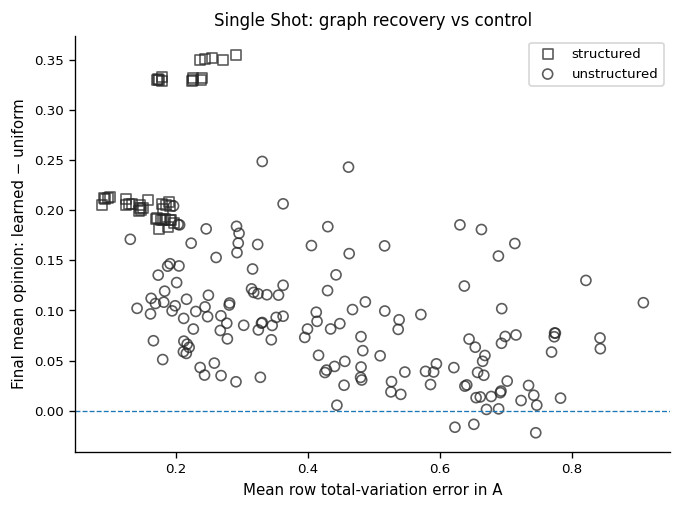

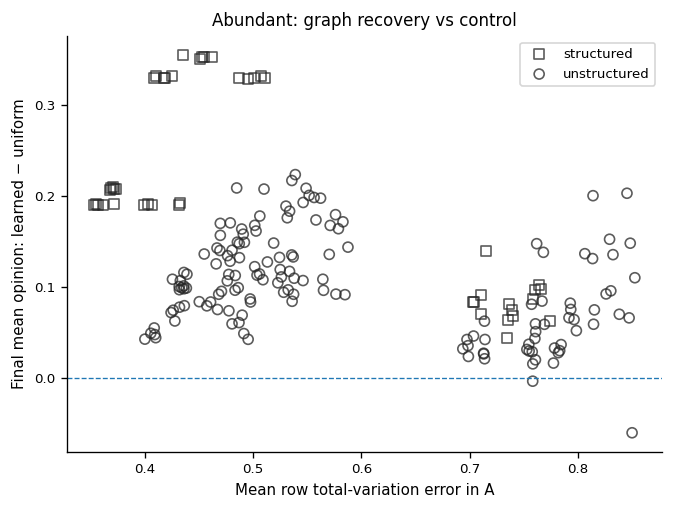

In [11]:
if not WORKER_MODE:
    DYNAMICS_LABELS = {
        "laplacian": "Linear",
        "coca": "COCA",
        "hegselmannkrause": "HK",
        "friedkinjohnsen": "FJ",
        "nonlinearinfluence": "Nonlinear",
        "repulsion": "Repulsion",
    }
    DYNAMICS_ORDER = [
        "laplacian", "coca", "hegselmannkrause",
        "friedkinjohnsen", "nonlinearinfluence", "repulsion",
    ]

    mpl.rcdefaults()
    mpl.rcParams.update({
        "font.family": "sans-serif",
        "font.size": 9,
        "axes.titlesize": 10,
        "axes.labelsize": 9,
        "legend.fontsize": 8,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "savefig.bbox": "tight",
    })

    def save_fig(fig, stem):
        fig.savefig(PLOT_DIR / f"{stem}.png")
        fig.savefig(PLOT_DIR / f"{stem}.pdf")

    corr_rows = []
    for regime, regime_df in RECOVERY_ENV.groupby("regime"):
        for scope, scope_df in [
            ("all", regime_df),
            ("unstructured_random", regime_df[regime_df["scenario_class"] == "unstructured_random"]),
            ("structured_mechanism", regime_df[regime_df["scenario_class"] == "structured_mechanism"]),
        ]:
            for metric in ["A_MAE", "row_TV", "true_edge_mass", "support_topdegree_recall", "edge_AP", "centrality_L1"]:
                x = scope_df[metric].to_numpy(float)
                y = scope_df["control_gain"].to_numpy(float)
                good = np.isfinite(x) & np.isfinite(y)
                if good.sum() >= 3 and np.unique(x[good]).size >= 2 and np.unique(y[good]).size >= 2:
                    r = spearmanr(x[good], y[good])
                    rho, p = float(r.statistic), float(r.pvalue)
                else:
                    rho, p = np.nan, np.nan
                corr_rows.append({
                    "regime": regime,
                    "scope": scope,
                    "metric": metric,
                    "n": int(good.sum()),
                    "spearman_rho": rho,
                    "p_value": p,
                })

    RECOVERY_CONTROL_CORR = pd.DataFrame(corr_rows)
    RECOVERY_CONTROL_CORR.to_csv(
        TABLE_DIR / "paper_table_A_recovery_vs_control_spearman.csv",
        index=False,
    )
    display(RECOVERY_CONTROL_CORR.round(5))

    # Scatter: row-TV versus control gain.
    for regime in ["single_shot", "abundant"]:
        g = RECOVERY_ENV[RECOVERY_ENV["regime"] == regime]
        fig, ax = plt.subplots(figsize=(6.4, 4.5))
        for scenario_class, sg in g.groupby("scenario_class"):
            marker = "o" if scenario_class == "unstructured_random" else "s"
            label = "unstructured" if scenario_class == "unstructured_random" else "structured"
            ax.scatter(
                sg["row_TV"],
                sg["control_gain"],
                marker=marker,
                facecolors="none",
                edgecolors="0.15",
                alpha=0.75,
                label=label,
            )
        ax.axhline(0.0, linewidth=0.8, linestyle="--")
        ax.set_xlabel("Mean row total-variation error in A")
        ax.set_ylabel("Final mean opinion: learned − uniform")
        ax.set_title(f"{regime.replace('_', ' ').title()}: graph recovery vs control")
        ax.legend()
        save_fig(fig, f"01_{regime}_rowTV_vs_control_gain")
        plt.show()
        plt.close(fig)


## Recovery quality by dynamics

The next figures directly compare the two data regimes on the same graph
identification metrics.


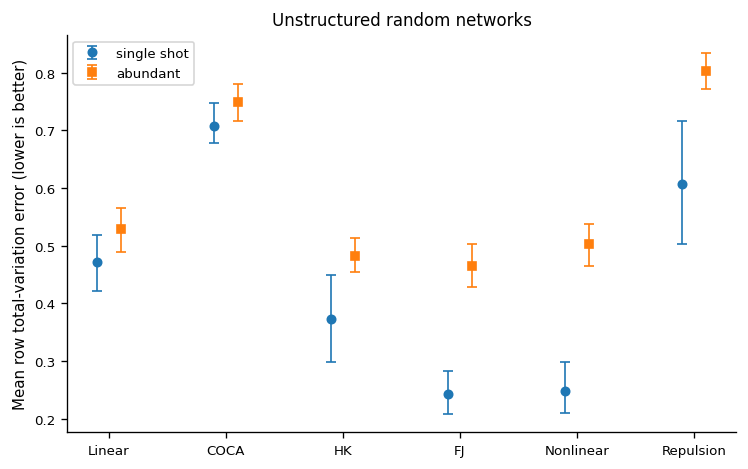

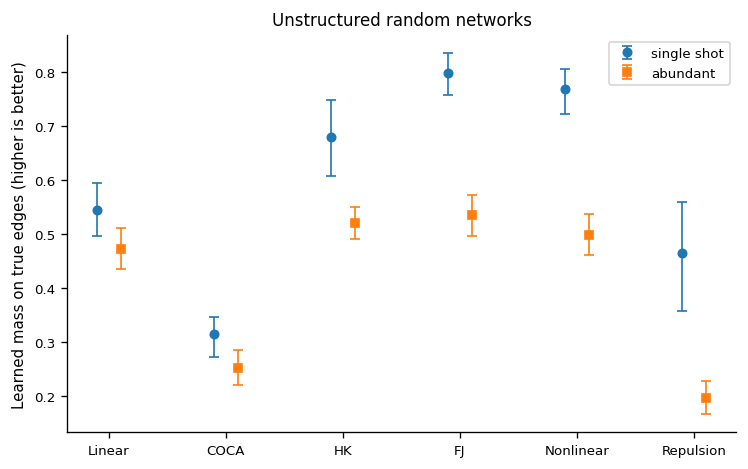

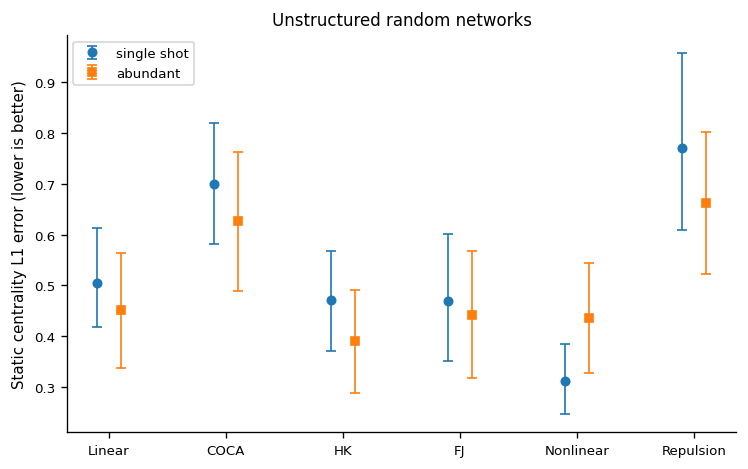

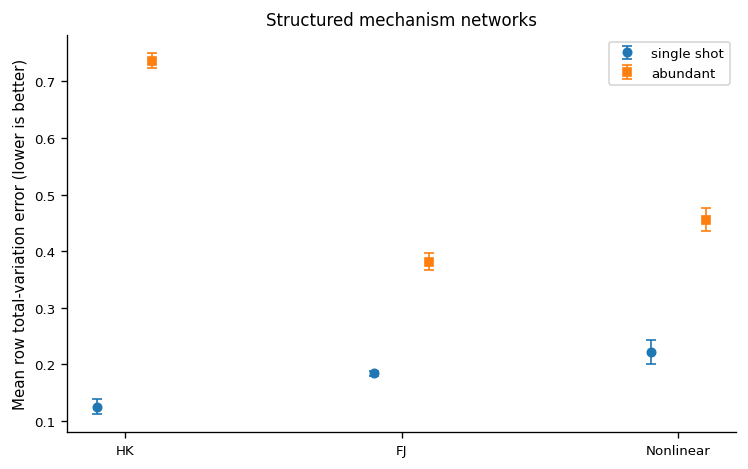

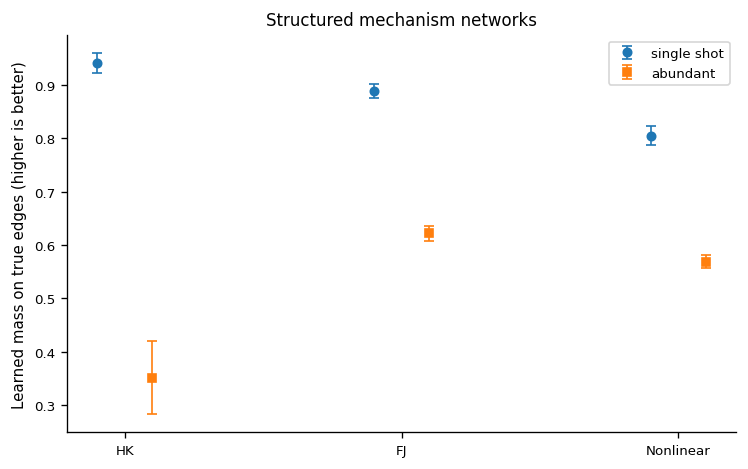

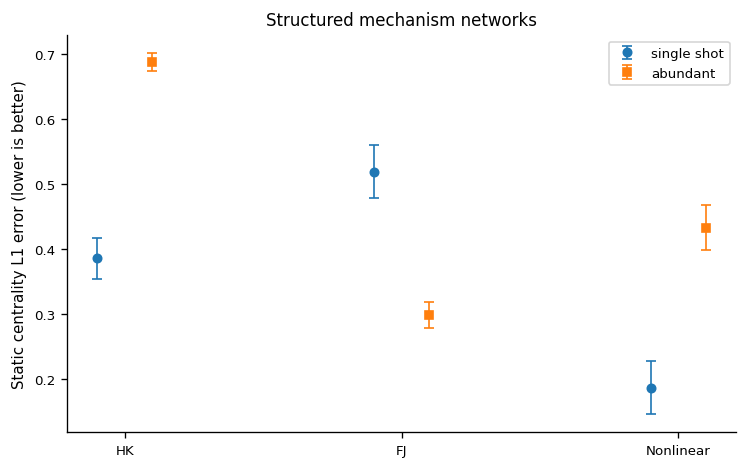

In [12]:
if not WORKER_MODE:
    def point_ci_plot(metric: str, ylabel: str, stem: str, scenario_class: str):
        sub = RECOVERY_BY_DYNAMICS[
            RECOVERY_BY_DYNAMICS["scenario_class"] == scenario_class
        ].copy()

        dyns = [
            d for d in DYNAMICS_ORDER
            if d in set(sub["dynamics"])
        ]
        x = np.arange(len(dyns), dtype=float)
        offsets = {"single_shot": -0.10, "abundant": 0.10}
        markers = {"single_shot": "o", "abundant": "s"}

        fig, ax = plt.subplots(figsize=(7.2, 4.3))
        for regime in ["single_shot", "abundant"]:
            rows = sub[sub["regime"] == regime].set_index("dynamics").reindex(dyns)
            means = rows[f"{metric}_mean"].to_numpy(float)
            lows = rows[f"{metric}_ci_low"].to_numpy(float)
            highs = rows[f"{metric}_ci_high"].to_numpy(float)
            yerr = np.vstack([means - lows, highs - means])
            ax.errorbar(
                x + offsets[regime],
                means,
                yerr=yerr,
                fmt=markers[regime],
                capsize=3,
                linewidth=1.0,
                markersize=5,
                label=regime.replace("_", " "),
            )
        ax.set_xticks(x)
        ax.set_xticklabels([DYNAMICS_LABELS[d] for d in dyns])
        ax.set_ylabel(ylabel)
        ax.set_title(
            ("Unstructured random networks" if scenario_class == "unstructured_random"
             else "Structured mechanism networks")
        )
        ax.legend()
        save_fig(fig, stem)
        plt.show()
        plt.close(fig)

    for scenario_class, suffix in [
        ("unstructured_random", "unstructured"),
        ("structured_mechanism", "structured"),
    ]:
        point_ci_plot(
            "row_TV",
            "Mean row total-variation error (lower is better)",
            f"02_{suffix}_rowTV_single_shot_vs_abundant",
            scenario_class,
        )
        point_ci_plot(
            "true_edge_mass",
            "Learned mass on true edges (higher is better)",
            f"03_{suffix}_true_edge_mass_single_shot_vs_abundant",
            scenario_class,
        )
        point_ci_plot(
            "centrality_L1",
            "Static centrality L1 error (lower is better)",
            f"04_{suffix}_centrality_single_shot_vs_abundant",
            scenario_class,
        )


## Representative weighted-\(A\) matrices

For each example below, learning seed 1 is shown for both regimes so the
visual comparison is fixed and non-cherry-picked.


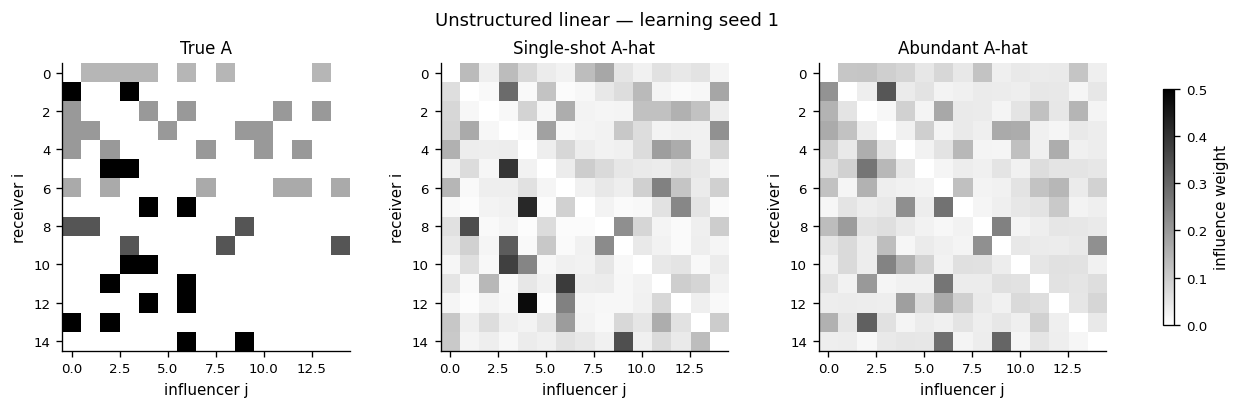

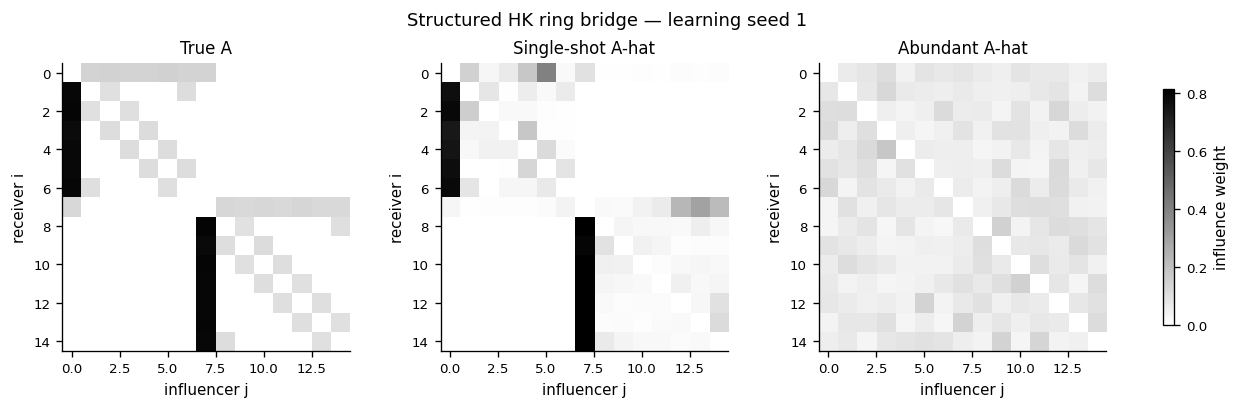

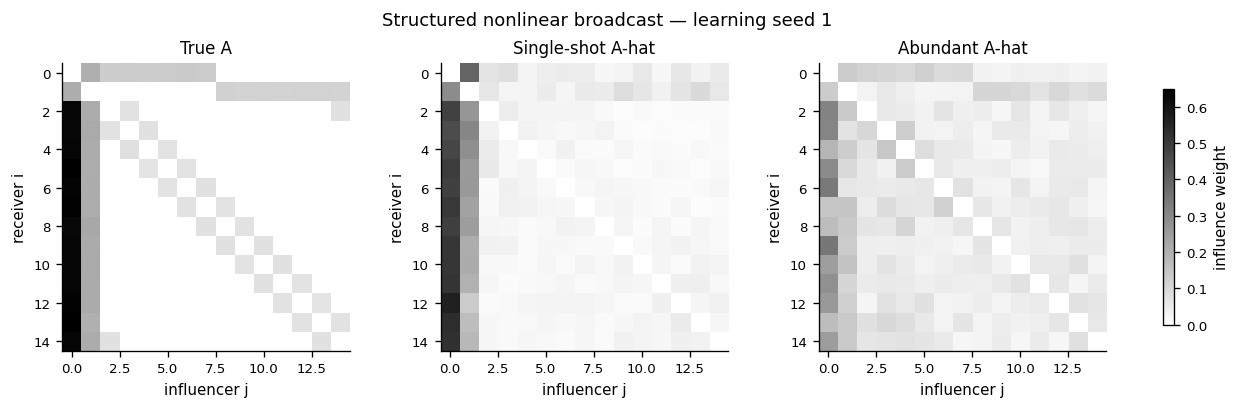

In [13]:
if not WORKER_MODE:
    CANONICAL = {
        "Unstructured linear": "unstructured__laplacian__topo03__x00",
        "Structured HK ring bridge": "structured__hegselmannkrause__ring_bridge__env00",
        "Structured nonlinear broadcast": "structured__nonlinearinfluence__asymmetric_broadcast__env00",
    }

    def load_ss_Ahat(env_id: str, seed: int = 1) -> np.ndarray:
        _, npath = derived_paths(env_id, seed)
        arrays = np.load(npath, allow_pickle=False)
        return np.asarray(arrays["A_hat"], dtype=float)

    def load_ab_Ahat(env_id: str, seed: int = 1) -> np.ndarray:
        path = AB_CACHE_ROOT / env_id / f"learned_seed_{seed:02d}_rollout.npz"
        arrays = np.load(path, allow_pickle=False)
        return np.asarray(arrays["A_hat"], dtype=float)

    for label, env_id in CANONICAL.items():
        A_true = np.asarray(TRUE_ENV[env_id]["A"], dtype=float)
        A_ss = load_ss_Ahat(env_id, 1)
        A_ab = load_ab_Ahat(env_id, 1)

        vmax = max(float(A_true.max()), float(A_ss.max()), float(A_ab.max()))
        fig, axes = plt.subplots(1, 3, figsize=(10.5, 3.3), constrained_layout=True)
        for ax, matrix, title in zip(
            axes,
            [A_true, A_ss, A_ab],
            ["True A", "Single-shot A-hat", "Abundant A-hat"],
        ):
            im = ax.imshow(matrix, vmin=0.0, vmax=vmax, cmap="gray_r", aspect="equal")
            ax.set_title(title)
            ax.set_xlabel("influencer j")
            ax.set_ylabel("receiver i")
        fig.colorbar(im, ax=axes, shrink=0.82, label="influence weight")
        fig.suptitle(f"{label} — learning seed 1")
        safe = (
            label.lower()
            .replace(" ", "_")
            .replace("-", "_")
        )
        save_fig(fig, f"05_A_matrix_{safe}")
        plt.show()
        plt.close(fig)


## Paper-facing combined table

This table places control and graph recovery in the same view. It is intended
to make statements such as “control remains strong even when full matrix
recovery is imperfect” directly testable from the paper outputs.


In [14]:
if not WORKER_MODE:
    PAPER_OVERVIEW = RECOVERY_BY_DYNAMICS[
        [
            "regime", "scenario_class", "dynamics", "n_environments",
            "control_gain_mean", "control_gain_ci_low", "control_gain_ci_high",
            "A_MAE_mean", "A_MAE_ci_low", "A_MAE_ci_high",
            "row_TV_mean", "row_TV_ci_low", "row_TV_ci_high",
            "true_edge_mass_mean", "true_edge_mass_ci_low", "true_edge_mass_ci_high",
            "support_topdegree_recall_mean",
            "support_topdegree_recall_ci_low",
            "support_topdegree_recall_ci_high",
            "edge_AP_mean", "edge_AP_ci_low", "edge_AP_ci_high",
            "centrality_L1_mean", "centrality_L1_ci_low", "centrality_L1_ci_high",
        ]
    ].copy()

    PAPER_OVERVIEW.to_csv(
        TABLE_DIR / "paper_table_control_and_A_recovery_overview.csv",
        index=False,
    )

    display(PAPER_OVERVIEW.round(5))

    manifest = pd.DataFrame([
        {
            "file": "paper_table_control_and_A_recovery_overview.csv",
            "purpose": "Main control + weighted-A recovery overview by regime, scenario and dynamics",
        },
        {
            "file": "paper_table_A_recovery_by_regime_dynamics.csv",
            "purpose": "Full A-recovery metrics and confidence intervals by regime/dynamics",
        },
        {
            "file": "paper_table_A_recovery_structured_families.csv",
            "purpose": "A recovery for each structured mechanism family",
        },
        {
            "file": "paper_table_A_recovery_abundant_vs_single_shot.csv",
            "purpose": "Paired environment-level abundant-minus-single-shot recovery deltas",
        },
        {
            "file": "paper_table_A_recovery_vs_control_spearman.csv",
            "purpose": "Rank correlations between graph-recovery quality and control gain",
        },
    ])
    manifest.to_csv(TABLE_DIR / "paper_table_A_recovery_manifest.csv", index=False)

    print("=" * 92)
    print("FINAL A-RECOVERY ANALYSIS COMPLETE")
    print("=" * 92)
    print("Derived single-shot replay cache:", DERIVED_SS_CACHE)
    print("Paper tables:", TABLE_DIR)
    print("Paper plots:", PLOT_DIR)
    print("Seed-level recovery:", A_RECOVERY_DIR / "A_recovery_seed_level.csv")
    print("Environment-level recovery:", A_RECOVERY_DIR / "A_recovery_environment_level.csv")
    print()
    print("Important interpretation:")
    print("  A_MAE / row_TV / centrality_L1: lower is better")
    print("  true_edge_mass / support_topdegree_recall / edge_AP: higher is better")


,regime,scenario_class,dynamics,n_environments,control_gain_mean,control_gain_ci_low,control_gain_ci_high,A_MAE_mean,A_MAE_ci_low,A_MAE_ci_high,row_TV_mean,row_TV_ci_low,row_TV_ci_high,true_edge_mass_mean,true_edge_mass_ci_low,true_edge_mass_ci_high,support_topdegree_recall_mean,support_topdegree_recall_ci_low,support_topdegree_recall_ci_high,edge_AP_mean,edge_AP_ci_low,edge_AP_ci_high,centrality_L1_mean,centrality_L1_ci_low,centrality_L1_ci_high
0,abundant,structured_mechanism,friedkinjohnsen,15,0.19647,0.19170,0.20124,0.05085,0.04889,0.05280,0.38136,0.36670,0.39603,0.62248,0.60835,0.63660,0.67553,0.65655,0.69451,0.83626,0.82207,0.85044,0.29765,0.27776,0.31755
1,abundant,structured_mechanism,hegselmannkrause,15,0.08327,0.07109,0.09545,0.09825,0.09647,0.10003,0.73688,0.72351,0.75024,0.35169,0.28277,0.42062,0.45422,0.40344,0.50499,0.48637,0.42815,0.54460,0.68752,0.67403,0.70101
2,abundant,structured_mechanism,nonlinearinfluence,15,0.33747,0.33137,0.34357,0.06077,0.05807,0.06348,0.45580,0.43551,0.47609,0.56860,0.55679,0.58040,0.75259,0.71332,0.79187,0.86383,0.82538,0.90229,0.43270,0.39871,0.46669
3,abundant,unstructured_random,coca,25,0.04080,0.02934,0.05602,0.09984,0.09549,0.10413,0.74878,0.71616,0.78095,0.25151,0.21937,0.28409,0.49733,0.47721,0.51812,0.51326,0.49403,0.53444,0.62615,0.48886,0.76321
4,abundant,unstructured_random,friedkinjohnsen,25,0.07709,0.05623,0.09878,0.06208,0.05707,0.06709,0.46561,0.42805,0.50320,0.53482,0.49714,0.57243,0.99739,0.99333,0.99991,0.96821,0.94380,0.98975,0.44220,0.31717,0.56709
5,abundant,unstructured_random,hegselmannkrause,25,0.14829,0.11628,0.18120,0.06432,0.06049,0.06847,0.48243,0.45365,0.51352,0.52120,0.49059,0.55012,0.97639,0.96647,0.98606,0.93622,0.90727,0.96383,0.38993,0.28821,0.49196
6,abundant,unstructured_random,laplacian,25,0.11977,0.09434,0.14718,0.07049,0.06525,0.07548,0.52869,0.48938,0.56609,0.47175,0.43421,0.51097,0.95166,0.92438,0.97597,0.92656,0.89476,0.95579,0.45119,0.33702,0.56465
7,abundant,unstructured_random,nonlinearinfluence,25,0.14130,0.11038,0.17417,0.06703,0.06187,0.07181,0.50274,0.46404,0.53854,0.49788,0.46184,0.53655,0.96510,0.94504,0.98442,0.93798,0.90986,0.96696,0.43568,0.32731,0.54501
8,abundant,unstructured_random,repulsion,25,0.09068,0.04813,0.12805,0.10712,0.10300,0.11125,0.80339,0.77252,0.83434,0.19679,0.16570,0.22776,0.21903,0.19325,0.24450,0.22453,0.19450,0.25472,0.66248,0.52182,0.80257
9,single_shot,structured_mechanism,friedkinjohnsen,15,0.19407,0.18927,0.19887,0.02451,0.02391,0.02511,0.18380,0.17931,0.18829,0.88825,0.87494,0.90156,0.68286,0.67111,0.69460,0.79174,0.77983,0.80366,0.51874,0.47793,0.55955


FINAL A-RECOVERY ANALYSIS COMPLETE
Derived single-shot replay cache: d:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\experiments\results\final_A_recovery_analysis_2026_09_19\derived_single_shot_A_cache
Paper tables: d:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\experiments\results\final_A_recovery_analysis_2026_09_19\paper_tables
Paper plots: d:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\experiments\results\final_A_recovery_analysis_2026_09_19\plots_paper_bw
Seed-level recovery: d:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\experiments\results\final_A_recovery_analysis_2026_09_19\A_recovery_seed_level.csv
Environment-level recovery: d:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\experiments\results\final_A_recovery_analysis_2026_09_19\A_recovery_environment_level.csv

Important interpretation:
  A_MAE / row_TV / centrality_L1: lower is better
  true_edge_mass / support_topdegree_recall / edge_AP: higher is better
